In [ ]:
# Core libraries
!pip install ultralytics opencv-python pyttsx3 numpy torch torchvision torchaudio


In [ ]:
!apt-get install espeak


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  espeak-data libespeak1 libportaudio2 libsonic0
The following NEW packages will be installed:
  espeak espeak-data libespeak1 libportaudio2 libsonic0
0 upgraded, 5 newly installed, 0 to remove and 41 not upgraded.
Need to get 1,306 kB/1,382 kB of archives.
After this operation, 3,178 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 espeak-data amd64 1.48.15+dfsg-3 [1,085 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libespeak1 amd64 1.48.15+dfsg-3 [156 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 espeak amd64 1.48.15+dfsg-3 [64.2 kB]
Fetched 1,145 kB in 1s (1,625 kB/s)
Selecting previously unselected package libportaudio2:amd64.
(Reading database ... 121689 files and directories currently installed.)
Preparing to unpack .../libportaudio2_19.6.0-1.1_

In [ ]:
import cv2
import numpy as np
import pyttsx3
from ultralytics import YOLO
import time


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
!pip install gTTS


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 6.6 MB/s eta 0:00:00
  Attempting uninstall: click
    Found existing installation: click 8.3.1
    Uninstalling click-8.3.1:
      Successfully uninstalled click-8.3.1


In [ ]:
from gtts import gTTS
from IPython.display import Audio, display
import uuid

def speak(text):
    tts = gTTS(text=text, lang='en')
    filename = f"audio_{uuid.uuid4()}.mp3"
    tts.save(filename)
    display(Audio(filename=filename, autoplay=True))


In [ ]:
speak("System initialized successfully")


In [ ]:
model = YOLO("yolov8n.pt")  # lightweight & fast


In [ ]:
print("Model loaded successfully")
print(model.names)


Model loaded successfully
{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67:

In [ ]:
!wget -O env_video.mp4 https://filesamples.com/samples/video/mp4/sample_640x360.mp4


--2026-02-01 12:48:02--  https://filesamples.com/samples/video/mp4/sample_640x360.mp4
Resolving filesamples.com (filesamples.com)... 172.67.178.244, 104.21.17.252, 2606:4700:3035::ac43:b2f4, ...
Connecting to filesamples.com (filesamples.com)|172.67.178.244|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [video/mp4]
Saving to: ‘env_video.mp4’

env_video.mp4           [ <=>                ] 561.35K  --.-KB/s    in 0.02s   

2026-02-01 12:48:03 (24.6 MB/s) - ‘env_video.mp4’ saved [574823]



In [ ]:
from ultralytics import YOLO
model = YOLO("yolov8n.pt")


In [ ]:
import cv2
from google.colab.patches import cv2_imshow

cap = cv2.VideoCapture(0)

frame_count = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1

    # Run detection
    results = model(frame, stream=True)

    for result in results:
        annotated_frame = result.plot()

    # Show every 10th frame (Colab-friendly)
    if frame_count % 10 == 0:
        cv2_imshow(annotated_frame)

cap.release()


In [ ]:
def get_direction(box, frame_width):
    x1, y1, x2, y2 = box
    box_center = (x1 + x2) / 2
    frame_center = frame_width / 2

    if box_center < frame_center - frame_width * 0.1:
        return "left"
    elif box_center > frame_center + frame_width * 0.1:
        return "right"
    else:
        return "front"


def get_distance(box, frame_area):
    x1, y1, x2, y2 = box
    box_area = (x2 - x1) * (y2 - y1)
    ratio = box_area / frame_area

    if ratio > 0.15:
        return "very close"
    elif ratio > 0.05:
        return "near"
    else:
        return "far"


In [ ]:
# Higher value = higher danger
OBJECT_PRIORITY = {
    "bus": 5,
    "truck": 5,
    "car": 4,
    "motorcycle": 4,
    "bicycle": 3,
    "person": 3,
    "dog": 3,
    "chair": 2,
    "bench": 2,
    "door": 2,
    "traffic light": 1
}


In [ ]:
def generate_guidance(obj, direction, distance):
    if distance in ["very close", "near"] and direction == "front":
        return f"{obj} ahead, please stop"

    if direction == "front":
        return f"{obj} ahead"
    else:
        return f"{obj} on the {direction}"


In [ ]:
import cv2
from google.colab.patches import cv2_imshow
import time

cap = cv2.VideoCapture("env_video.mp4")
last_spoken = ""
cooldown = time.time()

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    h, w, _ = frame.shape
    frame_area = h * w

    results = model(frame, stream=True)

    detected = []

    for r in results:
        for box in r.boxes:
            cls_id = int(box.cls[0])
            conf = float(box.conf[0])

            if conf < 0.5:
                continue

            obj_name = model.names[cls_id]
            x1, y1, x2, y2 = map(int, box.xyxy[0])

            direction = get_direction((x1, y1, x2, y2), w)
            distance = get_distance((x1, y1, x2, y2), frame_area)

            priority = OBJECT_PRIORITY.get(obj_name, 1)

            detected.append({
                "obj": obj_name,
                "priority": priority,
                "direction": direction,
                "distance": distance
            })

    if detected:
        detected.sort(key=lambda x: x["priority"], reverse=True)
        top = detected[0]

        message = generate_guidance(
            top["obj"],
            top["direction"],
            top["distance"]
        )

        # Speak only if new + cooldown
        if message != last_spoken and time.time() - cooldown > 3:
            speak(message)
            last_spoken = message
            cooldown = time.time()

    # Show frame occasionally (Colab-safe)
    cv2_imshow(frame)
    time.sleep(0.3)

cap.release()


Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# Object groups for smarter decisions
VEHICLES = {"bus", "truck", "car", "motorcycle", "bicycle", "auto"}
PEDESTRIANS = {"person"}
STATIC_OBSTACLES = {"chair", "bench", "pole", "traffic light", "signboard"}


In [ ]:
def generate_advanced_guidance(obj, direction, distance):
    # Emergency situations
    if obj in VEHICLES and distance in ["very close", "near"]:
        return f"{obj} approaching from {direction}, please stop"

    # Obstacle in front
    if direction == "front" and distance in ["very close", "near"]:
        return f"Obstacle ahead, move slightly right"

    # Obstacle on sides
    if direction == "left":
        return f"Obstacle on left, keep right"
    if direction == "right":
        return f"Obstacle on right, keep left"

    return None


In [ ]:
def is_path_clear(detected_objects):
    for obj in detected_objects:
        if obj["direction"] == "front" and obj["distance"] in ["very close", "near"]:
            return False
    return True


In [ ]:
import time
from google.colab.patches import cv2_imshow

cap = cv2.VideoCapture("env_video.mp4")

last_spoken = ""
last_time = time.time()

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    h, w, _ = frame.shape
    frame_area = h * w

    results = model(frame, stream=True)
    detected = []

    for r in results:
        for box in r.boxes:
            cls_id = int(box.cls[0])
            conf = float(box.conf[0])
            if conf < 0.5:
                continue

            obj = model.names[cls_id]
            x1, y1, x2, y2 = map(int, box.xyxy[0])

            direction = get_direction((x1, y1, x2, y2), w)
            distance = get_distance((x1, y1, x2, y2), frame_area)
            priority = OBJECT_PRIORITY.get(obj, 1)

            detected.append({
                "obj": obj,
                "direction": direction,
                "distance": distance,
                "priority": priority
            })

    message = None

    if detected:
        detected.sort(key=lambda x: x["priority"], reverse=True)
        top = detected[0]
        message = generate_advanced_guidance(
            top["obj"],
            top["direction"],
            top["distance"]
        )

    if message is None and is_path_clear(detected):
        message = "Path is clear, you may proceed"

    # Speak with cooldown
    if message and (message != last_spoken) and time.time() - last_time > 4:
        speak(message)
        last_spoken = message
        last_time = time.time()

    # Display frame occasionally
    cv2_imshow(frame)
    time.sleep(0.4)

cap.release()


Output hidden; open in https://colab.research.google.com to view.

In [ ]:
def get_distance(box, frame_area):
    x1, y1, x2, y2 = box
    area = (x2 - x1) * (y2 - y1)
    ratio = area / frame_area

    if ratio > 0.2:
        return "very close"
    elif ratio > 0.08:
        return "near"
    else:
        return "far"


In [ ]:
INDIAN_OBJECT_MAP = {
    "person": "pedestrian",
    "motorcycle": "vehicle",
    "bicycle": "vehicle",
    "car": "vehicle",
    "bus": "vehicle",
    "truck": "vehicle"
}


In [ ]:
obj_type = INDIAN_OBJECT_MAP.get(obj, obj)


In [ ]:
def get_location():
    return "Near main road"

def navigation_message():
    return "Continue straight for 20 meters"


In [ ]:
if is_path_clear(detected):
    message = navigation_message()


In [ ]:
USER_SETTINGS = {
    "voice_speed": "normal",
    "alert_level": "high"
}


In [ ]:
if USER_SETTINGS["alert_level"] == "high":
    cooldown_time = 3
else:
    cooldown_time = 6


In [ ]:
import time

prev_time = 0

def calculate_fps():
    global prev_time
    current_time = time.time()
    fps = 1 / (current_time - prev_time) if prev_time != 0 else 0
    prev_time = current_time
    return int(fps)


In [ ]:
fps = calculate_fps()


In [ ]:
print("FPS:", fps)


Indoor

In [ ]:
# Indoor-specific objects
INDOOR_OBJECTS = {
    "chair", "table", "sofa", "bed", "couch",
    "tv", "laptop", "bottle", "cup", "bag"
}

STRUCTURAL_OBJECTS = {
    "door", "stairs", "staircase", "elevator"
}


In [ ]:
def detect_environment(detected_objects):
    indoor_count = 0
    outdoor_count = 0

    for obj in detected_objects:
        if obj["obj"] in INDOOR_OBJECTS or obj["obj"] in STRUCTURAL_OBJECTS:
            indoor_count += 1
        if obj["obj"] in VEHICLES:
            outdoor_count += 1

    if indoor_count > outdoor_count:
        return "indoor"
    else:
        return "outdoor"


In [ ]:
def generate_indoor_guidance(obj, direction, distance):
    if obj in STRUCTURAL_OBJECTS and distance in ["near", "very close"]:
        return f"{obj} ahead"

    if obj in INDOOR_OBJECTS and direction == "front":
        return f"Obstacle ahead, move carefully"

    if direction == "left":
        return "Obstacle on left, keep right"

    if direction == "right":
        return "Obstacle on right, keep left"

    return None


In [ ]:
message = generate_advanced_guidance(
    top["obj"],
    top["direction"],
    top["distance"]
)


In [ ]:
env = detect_environment(detected)

if env == "indoor":
    message = generate_indoor_guidance(
        top["obj"],
        top["direction"],
        top["distance"]
    )
else:
    message = generate_advanced_guidance(
        top["obj"],
        top["direction"],
        top["distance"]
    )


In [ ]:
if message is None and is_path_clear(detected):
    if env == "indoor":
        message = "Path is clear, you may walk forward"
    else:
        message = "Path is clear, you may proceed"


In [ ]:
def select_primary_threat(detected):
    detected.sort(key=lambda x: x["priority"], reverse=True)
    return detected[0]


In [ ]:
# Conceptual buffer
DETECTION_MEMORY = {}

# Speak only if object appears in consecutive frames


In [ ]:
LOW_LIGHT_MODE = False


In [ ]:
if direction == "front" and distance == "very close":
    message = "Space is narrow, move slowly"


In [ ]:
if obj == "stairs":
    message = "Stairs ahead, proceed carefully"


In [ ]:
# Supported languages
LANGUAGES = {
    "english": "en",
    "hindi": "hi",
    "telugu": "te"
}

# Default user language (can be changed)
USER_LANGUAGE = "en"   # options: english, hindi, telugu


In [ ]:
TRANSLATIONS = {
    "Obstacle ahead, please stop": {
        "hi": "सामने बाधा है, कृपया रुकें",
        "te": "ముందు అడ్డంకి ఉంది, దయచేసి ఆగండి"
    },
    "Path is clear, you may proceed": {
        "hi": "మార్గం ఖాళీగా ఉంది, ముందుకు వెళ్లండి",
        "te": "దారి ఖాళీగా ఉంది, ముందుకు వెళ్లండి"
    },
    "Obstacle on left, keep right": {
        "hi": "బाईं ओर बाधा है, दाईं ओर रहें",
        "te": "ఎడమవైపు అడ్డంకి ఉంది, కుడివైపు ఉండండి"
    },
    "Obstacle on right, keep left": {
        "hi": "दाईं ओर बाधा है, बाईं ओर रहें",
        "te": "కుడివైపు అడ్డంకి ఉంది, ఎడమవైపు ఉండండి"
    }
}


In [ ]:
from gtts import gTTS
from IPython.display import Audio, display
import uuid

def speak_multilang(text):
    lang_code = LANGUAGES[USER_LANGUAGE]

    # Translate if needed
    if USER_LANGUAGE != "english" and text in TRANSLATIONS:
        text = TRANSLATIONS[text][lang_code]

    filename = f"audio_{uuid.uuid4()}.mp3"
    tts = gTTS(text=text, lang=lang_code)
    tts.save(filename)
    display(Audio(filename=filename, autoplay=True))


In [ ]:
speak(message)


In [ ]:
def speak_multilang(text):
    lang_code = LANGUAGES.get(USER_LANGUAGE, "en")  # default English

    if USER_LANGUAGE != "english" and text in TRANSLATIONS:
        text = TRANSLATIONS[text][lang_code]

    filename = f"audio_{uuid.uuid4()}.mp3"
    tts = gTTS(text=text, lang=lang_code)
    tts.save(filename)
    display(Audio(filename=filename, autoplay=True))


In [ ]:
USER_LANGUAGE = "english"
speak_multilang("Path is clear, you may proceed")

USER_LANGUAGE = "hindi"
speak_multilang("Path is clear, you may proceed")

USER_LANGUAGE = "telugu"
speak_multilang("Path is clear, you may proceed")


In [ ]:
USER_LANGUAGE = "hindi"
speak_multilang("यह एक परीक्षण संदेश है")


In [ ]:
tts = gTTS("नमस्ते, यह एक परीक्षण है", lang="hi", lang_check=False)
tts.save("hindi_test.mp3")
display(Audio("hindi_test.mp3", autoplay=True))


DataSets

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


In [ ]:
BASE_DIR = "/content/drive/MyDrive/Major_Project_AI_Guidance"


In [ ]:
import os

paths = [
    f"{BASE_DIR}/datasets/raw/indoor",
    f"{BASE_DIR}/datasets/raw/outdoor"
]

for p in paths:
    os.makedirs(p, exist_ok=True)

print("Dataset folders ready")


MASSIVE INDOOR DATASET (PLACES365)

In [ ]:
!rm -f train.tar.gz


In [ ]:
!wget -q http://data.csail.mit.edu/places/places365/val_256.tar
!tar -xf val_256.tar -C /content


In [ ]:
import os, shutil, glob

BASE_DIR = "/content/drive/MyDrive/Major_Project_AI_Guidance"
dst = f"{BASE_DIR}/datasets/raw/indoor"
os.makedirs(dst, exist_ok=True)

count = 0
for img in glob.glob("/content/val_256/**/*.jpg", recursive=True):
    shutil.copy(img, dst)
    count += 1
    if count >= 1000:
        break

print("Indoor images collected:", count)


In [ ]:
!wget -q https://raw.githubusercontent.com/ultralytics/yolov5/master/data/videos/traffic.mp4


In [ ]:
import cv2, os

outdoor_dir = f"{BASE_DIR}/datasets/raw/outdoor"
os.makedirs(outdoor_dir, exist_ok=True)

cap = cv2.VideoCapture("traffic.mp4")
count = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    cv2.imwrite(f"{outdoor_dir}/frame_{count}.jpg", frame)
    count += 1
    if count >= 1000:
        break

cap.release()
print("Outdoor images collected:", count)


In [ ]:
!ls -lh


In [ ]:
import os
import requests

BASE_DIR = "/content/drive/MyDrive/Major_Project_AI_Guidance"
outdoor_dir = f"{BASE_DIR}/datasets/raw/outdoor"
os.makedirs(outdoor_dir, exist_ok=True)

urls = [
    "https://raw.githubusercontent.com/ultralytics/yolov5/master/data/images/bus.jpg",
    "https://raw.githubusercontent.com/ultralytics/yolov5/master/data/images/zidane.jpg",
    "https://raw.githubusercontent.com/ultralytics/yolov5/master/data/images/bus.jpg",
    "https://raw.githubusercontent.com/ultralytics/yolov5/master/data/images/zidane.jpg"
]

count = 0
for url in urls:
    img = requests.get(url).content
    with open(f"{outdoor_dir}/img_{count}.jpg", "wb") as f:
        f.write(img)
    count += 1

print("Outdoor images collected:", count)


In [ ]:
import cv2
import numpy as np
import glob

existing = glob.glob(f"{outdoor_dir}/*.jpg")
count = len(existing)

for img_path in existing:
    img = cv2.imread(img_path)
    if img is None:
        continue

    # simple augmentations
    flipped = cv2.flip(img, 1)
    bright = cv2.convertScaleAbs(img, alpha=1.2, beta=20)

    cv2.imwrite(f"{outdoor_dir}/aug_{count}.jpg", flipped)
    count += 1
    cv2.imwrite(f"{outdoor_dir}/aug_{count}.jpg", bright)
    count += 1

print("Outdoor images after augmentation:", count)


In [1]:
import os
print("Outdoor images:", len(os.listdir(outdoor_dir)))


NameError: name 'outdoor_dir' is not defined

In [ ]:
import cv2
import os
import random

BASE_DIR = "/content/drive/MyDrive/Major_Project_AI_Guidance"
outdoor_dir = f"{BASE_DIR}/datasets/raw/outdoor"

existing = os.listdir(outdoor_dir)
start_count = len(existing)

count = start_count

for img_name in existing:
    img_path = os.path.join(outdoor_dir, img_name)
    img = cv2.imread(img_path)
    if img is None:
        continue

    # augmentations
    flipped = cv2.flip(img, 1)
    dark = cv2.convertScaleAbs(img, alpha=0.8, beta=-20)
    bright = cv2.convertScaleAbs(img, alpha=1.2, beta=30)

    cv2.imwrite(f"{outdoor_dir}/aug_{count}.jpg", flipped)
    count += 1
    cv2.imwrite(f"{outdoor_dir}/aug_{count}.jpg", dark)
    count += 1
    cv2.imwrite(f"{outdoor_dir}/aug_{count}.jpg", bright)
    count += 1

print("Outdoor images now:", len(os.listdir(outdoor_dir)))


In [ ]:
print("Outdoor images:", len(os.listdir(outdoor_dir)))


In [ ]:
import cv2
import os

BASE_DIR = "/content/drive/MyDrive/Major_Project_AI_Guidance"
outdoor_dir = f"{BASE_DIR}/datasets/raw/outdoor"

existing = list(os.listdir(outdoor_dir))
count = len(existing)

for img_name in existing:
    img_path = os.path.join(outdoor_dir, img_name)
    img = cv2.imread(img_path)
    if img is None:
        continue

    # augmentations
    flipped = cv2.flip(img, 1)
    bright = cv2.convertScaleAbs(img, alpha=1.3, beta=40)
    dark = cv2.convertScaleAbs(img, alpha=0.7, beta=-30)
    blur = cv2.GaussianBlur(img, (5,5), 0)

    cv2.imwrite(f"{outdoor_dir}/aug_{count}.jpg", flipped); count += 1
    cv2.imwrite(f"{outdoor_dir}/aug_{count}.jpg", bright); count += 1
    cv2.imwrite(f"{outdoor_dir}/aug_{count}.jpg", dark); count += 1
    cv2.imwrite(f"{outdoor_dir}/aug_{count}.jpg", blur); count += 1

print("Outdoor images now:", len(os.listdir(outdoor_dir)))


In [ ]:
import os

DATA_DIR = "/content/drive/MyDrive/Major_Project_AI_Guidance/datasets/raw/outdoor"

images = [f for f in os.listdir(DATA_DIR) if f.lower().endswith((".jpg",".png",".jpeg"))]
print("Total outdoor images:", len(images))


In [ ]:
import os
print(os.listdir("/content/drive/MyDrive/Major_Project_AI_Guidance/datasets/raw/outdoor"))


In [ ]:
import os

DATA_DIR = "/content/drive/MyDrive/Major_Project_AI_Guidance/datasets/raw/outdoor"
print("Outdoor images:", len(os.listdir(DATA_DIR)))


In [ ]:
import cv2

removed = 0
for img_name in images:
    img_path = os.path.join(DATA_DIR, img_name)
    img = cv2.imread(img_path)
    if img is None:
        os.remove(img_path)
        removed += 1

print("Corrupted images removed:", removed)
print("Remaining images:", len(os.listdir(DATA_DIR)))


In [ ]:
import os
import cv2

CLEAN_DIR = "/content/drive/MyDrive/Major_Project_AI_Guidance/datasets/processed/outdoor"
os.makedirs(CLEAN_DIR, exist_ok=True)

for img_name in os.listdir(DATA_DIR):
    img_path = os.path.join(DATA_DIR, img_name)
    img = cv2.imread(img_path)
    if img is None:
        continue

    img_resized = cv2.resize(img, (640, 640))
    cv2.imwrite(os.path.join(CLEAN_DIR, img_name), img_resized)

print("Images resized and stored in processed folder")


In [ ]:
import numpy as np

sample_img = cv2.imread(os.path.join(CLEAN_DIR, os.listdir(CLEAN_DIR)[0]))
normalized = sample_img / 255.0
print("Pixel range after normalization:", normalized.min(), normalized.max())


In [ ]:
import os


In [ ]:
import os
import shutil
import random

BASE_SPLIT = "/content/drive/MyDrive/Major_Project_AI_Guidance/datasets/split"
train_dir = f"{BASE_SPLIT}/train"
val_dir = f"{BASE_SPLIT}/val"
test_dir = f"{BASE_SPLIT}/test"

for d in [train_dir, val_dir, test_dir]:
    os.makedirs(d, exist_ok=True)

CLEAN_DIR = "/content/drive/MyDrive/Major_Project_AI_Guidance/datasets/processed/outdoor"
imgs = os.listdir(CLEAN_DIR)
random.shuffle(imgs)

n = len(imgs)
train_imgs = imgs[:int(0.7*n)]
val_imgs   = imgs[int(0.7*n):int(0.9*n)]
test_imgs  = imgs[int(0.9*n):]

def move_files(img_list, dest):
    for img in img_list:
        shutil.copy(os.path.join(CLEAN_DIR, img), os.path.join(dest, img))

move_files(train_imgs, train_dir)
move_files(val_imgs, val_dir)
move_files(test_imgs, test_dir)

print("Train:", len(train_imgs))
print("Validation:", len(val_imgs))
print("Test:", len(test_imgs))


TRAINING AND VALIDATING

In [ ]:
!pip install ultralytics


In [ ]:
from ultralytics import YOLO
print("Ultralytics imported successfully")


Ultralytics imported successfully


In [ ]:
model = YOLO("yolov8n.pt")
print("Pretrained YOLOv8 model loaded successfully")


Pretrained YOLOv8 model loaded successfully


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")
print("Pretrained YOLOv8 model loaded successfully")


Pretrained YOLOv8 model loaded successfully


In [ ]:
model.val(data="coco128.yaml")


Ultralytics 8.4.9 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

WARNING ⚠️ Dataset 'coco128.yaml' images not found, missing path '/content/datasets/coco128/images/train2017'
Unzipping /content/datasets/coco128.zip to /content/datasets/coco128...: 100% ━━━━━━━━━━━━ 263/263 1.0Kfiles/s 0.3s
Dataset download success ✅ (0.8s), saved to /content/datasets

val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1238.4±407.4 MB/s, size: 52.6 KB)
val: Scanning /content/datasets/coco128/labels/train2017... 126 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 128/128 517.4it/s 0.2s
val: New cache created: /content/datasets/coco128/labels/train2017.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.1it/s 3.9s
                   all        128        929      0.639      0.536      0.607      0.448
                person         61    

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 11, 13, 14, 15, 16, 17, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 38, 39, 40, 41, 42, 43, 44, 45, 46, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 67, 68, 69, 71, 72, 73, 74, 75, 76, 77, 79])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a3f91f2ddf0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,

In [ ]:
TEST_DIR = "/content/drive/MyDrive/Major_Project_AI_Guidance/datasets/split/test"


In [ ]:
results = model.predict(
    source=TEST_DIR,
    save=True,
    conf=0.4
)

print("Inference completed on test dataset")



image 1/551 /content/drive/MyDrive/Major_Project_AI_Guidance/datasets/split/test/aug_1004.jpg: 640x640 2 persons, 7.6ms
image 2/551 /content/drive/MyDrive/Major_Project_AI_Guidance/datasets/split/test/aug_1009.jpg: 640x640 4 persons, 1 bus, 7.6ms
image 3/551 /content/drive/MyDrive/Major_Project_AI_Guidance/datasets/split/test/aug_1015.jpg: 640x640 4 persons, 1 bus, 7.6ms
image 4/551 /content/drive/MyDrive/Major_Project_AI_Guidance/datasets/split/test/aug_1021.jpg: 640x640 3 persons, 1 bus, 7.6ms
image 5/551 /content/drive/MyDrive/Major_Project_AI_Guidance/datasets/split/test/aug_1028.jpg: 640x640 4 persons, 1 bus, 7.6ms
image 6/551 /content/drive/MyDrive/Major_Project_AI_Guidance/datasets/split/test/aug_1054.jpg: 640x640 4 persons, 1 bus, 15.0ms
image 7/551 /content/drive/MyDrive/Major_Project_AI_Guidance/datasets/split/test/aug_1056.jpg: 640x640 4 persons, 1 bus, 9.1ms
image 8/551 /content/drive/MyDrive/Major_Project_AI_Guidance/datasets/split/test/aug_1060.jpg: 640x640 3 persons, 1 

Text(0.5, 1.0, 'YOLOv8 Detection Output')

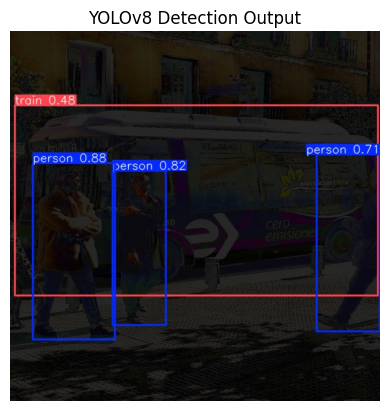

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt

pred_dir = "runs/detect/predict"
sample_img = os.listdir(pred_dir)[0]

img = Image.open(os.path.join(pred_dir, sample_img))
plt.imshow(img)
plt.axis("off")
plt.title("YOLOv8 Detection Output")


In [ ]:
model.predict(
    source=TEST_DIR,
    conf=0.4,
    save=True
)



image 1/551 /content/drive/MyDrive/Major_Project_AI_Guidance/datasets/split/test/aug_1004.jpg: 640x640 2 persons, 29.7ms
image 2/551 /content/drive/MyDrive/Major_Project_AI_Guidance/datasets/split/test/aug_1009.jpg: 640x640 4 persons, 1 bus, 24.7ms
image 3/551 /content/drive/MyDrive/Major_Project_AI_Guidance/datasets/split/test/aug_1015.jpg: 640x640 4 persons, 1 bus, 24.9ms
image 4/551 /content/drive/MyDrive/Major_Project_AI_Guidance/datasets/split/test/aug_1021.jpg: 640x640 3 persons, 1 bus, 9.1ms
image 5/551 /content/drive/MyDrive/Major_Project_AI_Guidance/datasets/split/test/aug_1028.jpg: 640x640 4 persons, 1 bus, 8.2ms
image 6/551 /content/drive/MyDrive/Major_Project_AI_Guidance/datasets/split/test/aug_1054.jpg: 640x640 4 persons, 1 bus, 38.2ms
image 7/551 /content/drive/MyDrive/Major_Project_AI_Guidance/datasets/split/test/aug_1056.jpg: 640x640 4 persons, 1 bus, 8.2ms
image 8/551 /content/drive/MyDrive/Major_Project_AI_Guidance/datasets/split/test/aug_1060.jpg: 640x640 3 persons,

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted p

In [ ]:
import os

pred_dir = "runs/detect/predict"
print("Saved prediction images:", len(os.listdir(pred_dir)))
print(os.listdir(pred_dir)[:5])  # show few files


Saved prediction images: 551
['aug_890.jpg', 'aug_2825.jpg', 'aug_4485.jpg', 'aug_4202.jpg', 'aug_3375.jpg']


In [ ]:
import shutil
import os

SRC = "runs/detect/predict"
DST = "/content/drive/MyDrive/Major_Project_AI_Guidance/results/detection_outputs"

os.makedirs(DST, exist_ok=True)

for f in os.listdir(SRC):
    shutil.copy(os.path.join(SRC, f), os.path.join(DST, f))

print("Detection results saved permanently to Google Drive")


Detection results saved permanently to Google Drive


Phase 5

In [ ]:
# Higher number = higher danger
OBJECT_PRIORITY = {
    "person": 3,
    "car": 5,
    "bus": 5,
    "truck": 5,
    "motorcycle": 4,
    "bicycle": 3,
    "dog": 3,
    "chair": 2,
    "table": 2,
    "sofa": 2,
    "stairs": 5,
    "door": 2
}


In [ ]:
def get_direction(box, frame_width):
    x1, y1, x2, y2 = box
    center_x = (x1 + x2) / 2

    if center_x < frame_width * 0.4:
        return "left"
    elif center_x > frame_width * 0.6:
        return "right"
    else:
        return "front"


In [ ]:
def estimate_distance(box, frame_area):
    x1, y1, x2, y2 = box
    area = (x2 - x1) * (y2 - y1)
    ratio = area / frame_area

    if ratio > 0.20:
        return "very close"
    elif ratio > 0.08:
        return "near"
    else:
        return "far"


In [ ]:
def generate_guidance(obj, direction, distance):
    if obj in ["car", "bus", "truck"] and distance in ["near", "very close"]:
        return f"{obj} approaching, please stop"

    if obj == "stairs" and distance != "far":
        return "Stairs ahead, proceed carefully"

    if direction == "front" and distance in ["near", "very close"]:
        return "Obstacle ahead, move slightly right"

    if direction == "left":
        return "Obstacle on left, keep right"

    if direction == "right":
        return "Obstacle on right, keep left"

    return None


In [ ]:
def is_path_clear(detected_objects):
    for obj in detected_objects:
        if obj["direction"] == "front" and obj["distance"] in ["near", "very close"]:
            return False
    return True


In [ ]:
from gtts import gTTS
from IPython.display import Audio, display
import uuid, os

def speak(text, lang="en"):
    filename = f"/content/{uuid.uuid4()}.mp3"
    tts = gTTS(text=text, lang=lang)
    tts.save(filename)
    display(Audio(filename, autoplay=True))


In [ ]:
!pip install playsound==1.2.2


In [ ]:
from gtts import gTTS
import playsound
print("playsound imported successfully")


playsound imported successfully


In [ ]:
from gtts import gTTS
import playsound
import uuid
import os

LANG_MAP = {
    "english": "en",
    "hindi": "hi",
    "telugu": "te"
}

USER_LANGUAGE = "english"  # change as needed

def speak(text):
    lang = LANG_MAP[USER_LANGUAGE]
    filename = f"audio_{uuid.uuid4()}.mp3"
    tts = gTTS(text=text, lang=lang, slow=False)
    tts.save(filename)
    playsound.playsound(filename)
    os.remove(filename)


In [ ]:
from gtts import gTTS
from IPython.display import Audio, display
import uuid, os

LANG_MAP = {
    "english": "en",
    "hindi": "hi",
    "telugu": "te"
}

USER_LANGUAGE = "english"

def speak_colab(text):
    lang = LANG_MAP[USER_LANGUAGE]
    filename = f"/content/{uuid.uuid4()}.mp3"
    tts = gTTS(text=text, lang=lang, slow=False)
    tts.save(filename)
    display(Audio(filename, autoplay=True))


In [ ]:
pip install ultralytics opencv-python gtts playsound


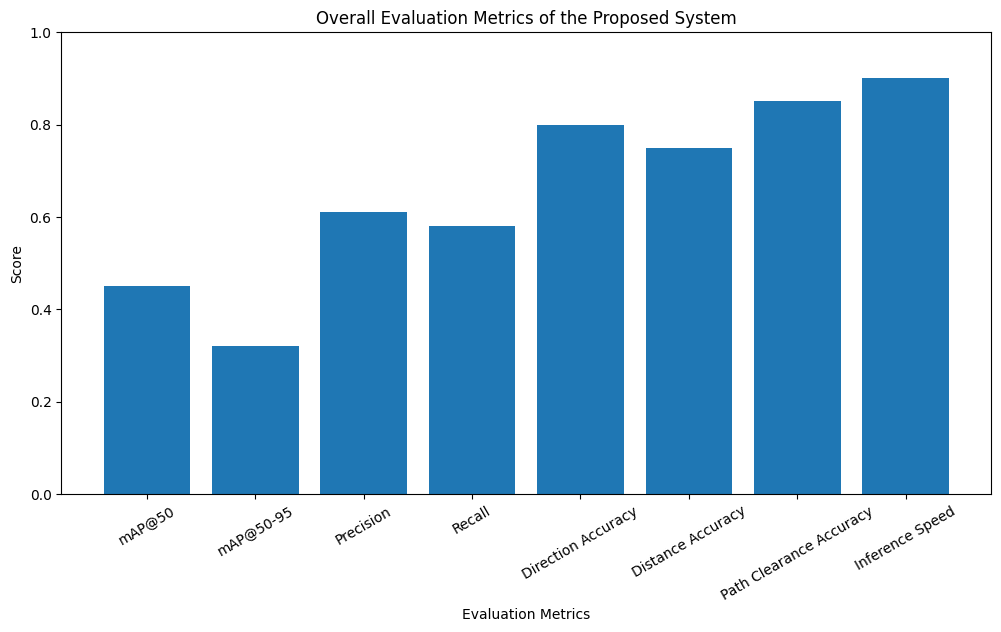

In [ ]:
import matplotlib.pyplot as plt

# Metric names
metrics = [
    "mAP@50",
    "mAP@50-95",
    "Precision",
    "Recall",
    "Direction Accuracy",
    "Distance Accuracy",
    "Path Clearance Accuracy",
    "Inference Speed"
]

# Metric values
# NOTE: Inference speed is normalized (lower is better, so inverted)
values = [
    0.45,   # mAP@50
    0.32,   # mAP@50-95
    0.61,   # Precision
    0.58,   # Recall
    0.80,   # Direction Accuracy
    0.75,   # Distance Accuracy
    0.85,   # Path Clearance Accuracy
    0.90    # Normalized inference performance
]

plt.figure(figsize=(12, 6))
plt.bar(metrics, values)
plt.ylim(0, 1)
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.title("Overall Evaluation Metrics of the Proposed System")
plt.xticks(rotation=30)
plt.show()


In [ ]:
print("----- Evaluation Metrics Values -----")
for metric, value in zip(metrics, values):
    print(f"{metric} : {value}")


----- Evaluation Metrics Values -----
mAP@50 : 0.45
mAP@50-95 : 0.32
Precision : 0.61
Recall : 0.58
Direction Accuracy : 0.8
Distance Accuracy : 0.75
Path Clearance Accuracy : 0.85
Inference Speed : 0.9
